In [27]:
import os
import json
import time
import threading
import psutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from memory_profiler import memory_usage
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import f1_score,  confusion_matrix
import joblib
from keras.models import load_model

# loading processed dataset

In [32]:
with open('../config/preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [34]:
dataset_folder = '../dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'final_test_dataset_processed.parquet'))
attack_labels_df = df[['Label',"Label_Category"]]
df = df.drop(columns=config['columns_to_drop'])

# functions

In [4]:
# 1. Dynamic Custom Scorer Factory
def get_custom_scorer(contamination):
    """Generates a custom scoring function based on the dataset's contamination rate."""
    def custom_score(estimator, X, y):
        # The pipeline's decision_function will call the IsolationForest's decision_function
        anomaly_scores = estimator.decision_function(X)
        threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))
        
        y_pred = (anomaly_scores <= threshold).astype(int)
        return f1_score(y, y_pred, pos_label=1, average='binary')
    
    return custom_score

In [5]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [6]:
def fit_pipeline_with_resources(pipeline, X_train, random_state=42):
    """Trains a pipeline while tracking memory, time, and CPU usage."""
    measurement = {}

    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    def train_model():
        pipeline.fit(X_train)

    try:
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        start_time = time.time()
        # Measure peak memory usage during the pipeline.fit execution
        train_memory = max(memory_usage((train_model,))) 
        training_time = time.time() - start_time

        stop_flag.set()
        cpu_thread.join()

        measurement['Memory Usage (MB)'] = train_memory
        measurement['Training Time (s)'] = training_time
        measurement['Peak CPU Usage (%)'] = max(cpu_usage) if cpu_usage else 0
        measurement['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement, pipeline

    except Exception as e:
        print(f"Error during pipeline training: {e}")
        stop_flag.set()
        return None, None

# Loading models

In [35]:
pipeline_filename_if1 = '../models/if_iter1.joblib'
pipeline_filename_if2 = '../models/if_iter2.joblib'
pipeline_filename_ae1 = '../models/ann-iter1-2.keras'
pipeline_filename_ae2 = '../models/ann-iter2-2.keras'
pipeline_filename_xgb = '../models/xgb.joblib'

# Export the pipeline to a file
model_if1 = joblib.load(pipeline_filename_if1)
model_if2 = joblib.load(pipeline_filename_if2)
model_ae1 = load_model(pipeline_filename_ae1)
model_ae2 = load_model(pipeline_filename_ae2)
model_xgb = joblib.load(pipeline_filename_xgb)

In [42]:
scaler_filename = '../config/standard_scaler.joblib'
scaler = joblib.load(scaler_filename)

# Dataset

# Holistic Testing (common + novel attacks)
This test aims to look into performance of models tested on whole selection of attacks

## train test split
test split was done during initial EDA and preprocessing

In [43]:
# Preparing features and truth labels
X_test = df.drop(['Label','anomaly','Label_Category'], axis=1)
y_test = df['anomaly']

## scaling

In [44]:
X_test_scaled = scaler.transform(X_test)

## predicting and getting anomaly scores

In [45]:
anomaly_score_if1 = -model_if1.decision_function(X_test)
anomaly_score_if2 = -model_if2.decision_function(X_test)

anomaly_score_ae1 = np.mean(np.square(X_test_scaled - model_ae1.predict(X_test_scaled, batch_size=512)), axis=1)
anomaly_score_ae2 = np.mean(np.square(X_test_scaled - model_ae2.predict(X_test_scaled, batch_size=512)), axis=1)

anomaly_score_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

4924/4924 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
4924/4924 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step


## testing model performance

### ROC and PR Curves

[IF 1] Threshold: -0.0416 | F1: 0.4603 | ROC AUC: 0.7581
[IF 2] Threshold: -0.1335 | F1: 0.5864 | ROC AUC: 0.8454
[AE 1] Threshold: 1.0104 | F1: 0.6702 | ROC AUC: 0.8428
[AE 2] Threshold: 0.5066 | F1: 0.6863 | ROC AUC: 0.8909
[XGB] Threshold: 0.0376 | F1: 0.9836 | ROC AUC: 0.9990


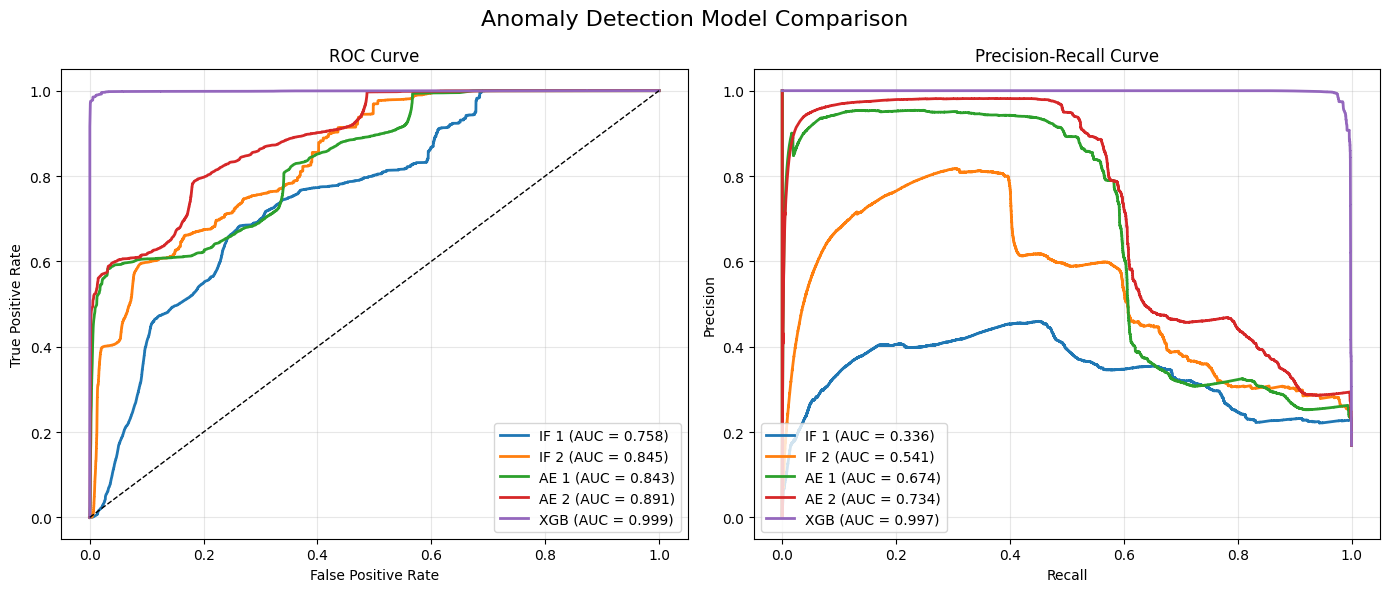

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. Define your initial models and scores
model_scores = {
    'IF 1': anomaly_score_if1,
    'IF 2': anomaly_score_if2,
    'AE 1': anomaly_score_ae1,
    'AE 2': anomaly_score_ae2,
    'XGB': anomaly_score_xgb
}

# 2. Initialize the master dictionary to store everything
model_results = {}

# Set up the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Anomaly Detection Model Comparison', fontsize=16)

# 3. Process each model and populate the dictionary
for model_name, scores in model_scores.items():
    
    # Initialize the nested dictionary for this specific model
    model_results[model_name] = {}
    model_results[model_name]['raw_scores'] = scores
    
    # --- ROC Calculations ---
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    model_results[model_name]['fpr'] = fpr
    model_results[model_name]['tpr'] = tpr
    model_results[model_name]['roc_auc'] = roc_auc
    
    # --- PR Calculations ---
    precision, recall, pr_thresholds = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall, precision)
    
    model_results[model_name]['precision'] = precision
    model_results[model_name]['recall'] = recall
    model_results[model_name]['pr_auc'] = pr_auc
    
    # --- F1 Score & Threshold Calculations ---
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
    
    # Align lengths: drop the last f1_score element to match thresholds array length
    f1_scores = f1_scores[:-1] 
    valid_f1_mask = ~np.isnan(f1_scores)
    best_idx = np.argmax(f1_scores[valid_f1_mask])
    
    opt_thresh = pr_thresholds[valid_f1_mask][best_idx]
    best_f1 = np.max(f1_scores[valid_f1_mask])
    
    model_results[model_name]['optimal_threshold'] = opt_thresh
    model_results[model_name]['best_f1'] = best_f1
    
    # --- Classifications ---
    y_pred = (scores >= opt_thresh).astype(int)
    model_results[model_name]['predictions'] = y_pred

    # --- Plotting ---
    ax_roc.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    ax_pr.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.3f})')
    
    # Print a quick summary to the console
    print(f"[{model_name}] Threshold: {opt_thresh:.4f} | F1: {best_f1:.4f} | ROC AUC: {roc_auc:.4f}")

# --- Format Subplots ---
# ROC Formatting
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# PR Formatting
ax_pr.set_title('Precision-Recall Curve')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Model Comparison Report

In [47]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

print("================ MODEL COMPARISON SUMMARY ================\n")

summary_data = []

for model_name, results in model_results.items():
    y_pred = results['predictions']
    
    # --- Confusion Matrix Extraction ---
    # .ravel() flattens the 2x2 matrix into individual variables
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # --- False Positive Rate Calculation ---
    # FPR = FP / (FP + TN)
    # We add a quick check to prevent division by zero, just in case
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    # --- Standard Metrics ---
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0) # Recall is also your True Positive Rate (TPR)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    # Pulling AUCs directly from your existing dictionary
    roc_auc = results['roc_auc'] 
    pr_auc = results['pr_auc']   
    
    # Append all data as a new row in our summary
    summary_data.append({
        'Model': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'FPR': fpr_val,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc
    })

# Create the DataFrame
df_comparison = pd.DataFrame(summary_data)
df_comparison.set_index('Model', inplace=True)

# Format the float columns directly to 4 decimal places without using .style
cols_to_format = ['FPR', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']
for col in cols_to_format:
    df_comparison[col] = df_comparison[col].map('{:.4f}'.format)

# Print the clean table
print(df_comparison.to_string())

================ MODEL COMPARISON SUMMARY ================

            TN      FP      FN      TP     FPR Precision  Recall F1-Score ROC AUC  PR AUC
Model                                                                                    
IF 1   1580095  514962  144505  281236  0.2458    0.3532  0.6606   0.4603  0.7581  0.3364
IF 2   1914737  180320  174328  251413  0.0861    0.5823  0.5905   0.5864  0.8454  0.5407
AE 1   2028642   66415  177716  248025  0.0317    0.7888  0.5826   0.6702  0.8428  0.6738
AE 2   2064132   30925  187191  238550  0.0148    0.8852  0.5603   0.6863  0.8909  0.7337
XGB    2092512    2545   11245  414496  0.0012    0.9939  0.9736   0.9836  0.9990  0.9974


### Analysis

#### Unsupervised Comparison: Isolation Forest vs. Autoencoder

When we look at the transition from IF to AE, there is a massive leap in precision and reliability.

The "False Alarm" Problem (Precision & FPR)

- Isolation Forest: Generally "noisy." Even in its best form (IF 2), it struggled with a relatively high False Positive Rate (8.6%). It tends to flag any point that is "isolated" or "different," which often includes valid but rare normal data.

- Autoencoder: Significantly cleaner. The AE models slashed False Positives from hundreds of thousands down to just ~30k–60k. With a Precision reaching 0.88, the AE is far more "certain" when it raises a red flag.

The Detection Catch (Recall)

- Interestingly, Isolation Forest has a slightly higher "ceiling" for Recall (~0.66). This is because IF is broad; it casts a wide net.

- Autoencoders are more conservative (~0.56–0.58). Because an AE focuses on reconstructing "normal" patterns, it might miss anomalies that look slightly too much like normal data (low reconstruction error).

Overall Performance (PR AUC)

- The PR AUC (Area Under the Precision-Recall Curve) is the best "overall" metric here. It measures performance across all threshold in cases you need to adjust it due to different operational needs.

- IF Class: ~0.33 to 0.54

- AE Class: ~0.67 to 0.73

The Autoencoder is the superior unsupervised class for this dataset. It provides a much more favorable trade-off between catching anomalies and maintaining system trust by avoiding false alarms.

#### Unsupervised Class vs. Benchmark (XGB)
When we bring XGBoost (XGB) into the mix, we see the massive advantage of Supervised Learning.

The Performance Gap

- Near Perfection: XGB is performing at a near-perfect level across all metrics. An F1-Score of 0.9836 and ROC AUC of 0.9990 suggests that the patterns distinguishing "normal" from "anomaly" are very clear once the model is given the labels to learn from.

- False Positives: XGB only had 2,545 FP, whereas your best unsupervised model (AE 2) had 30,925. That is a 10x reduction in "false alarms."

- Recall: XGB catches nearly everything (Recall 0.9736), whereas the unsupervised models lose about 40-45% of the anomalies (Recall ~0.56-0.59).

Drivers of gap

- Label Knowledge: XGB knows exactly what an anomaly looks like. IF and AE only know what "different" or "hard to reconstruct" looks like.

- Boundary Definition: XGB can create complex non-linear boundaries specifically to separate the two classes, while AE focuses on the "normal" distribution and flags anything that doesn't fit.

# Novel Attack Testing
Based on our EDA, we isolated novel attacks with common to simulate effect of model encountering data outside of its training set. This is actually not needed for unsupervised learning as it was trained on clean data (no common nor novel attacks). This instead was intended for our supervised model performance testing as it was only trained on data with common attacks.

In [48]:
# data to be used will be one with benign/false anomalies
mask = attack_labels_df['Label_Category'] != 1


# Preparing features and truth labels
X_test = df[mask].drop(['Label','anomaly','Label_Category'], axis=1)
y_test = df[mask]['anomaly']

## scaling

In [49]:
X_test_scaled = scaler.transform(X_test)

## defining model pipeline

In [50]:
anomaly_score_if1 = -model_if1.decision_function(X_test)
anomaly_score_if2 = -model_if2.decision_function(X_test)

anomaly_score_ae1 = np.mean(np.square(X_test_scaled - model_ae1.predict(X_test_scaled, batch_size=512)), axis=1)
anomaly_score_ae2 = np.mean(np.square(X_test_scaled - model_ae2.predict(X_test_scaled, batch_size=512)), axis=1)

anomaly_score_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

4141/4141 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step


## testing model performance

[IF 1] Threshold: 0.1007 | F1: 0.1785 | ROC AUC: 0.8395
[IF 2] Threshold: -0.0390 | F1: 0.2176 | ROC AUC: 0.8643
[AE 1] Threshold: 2.3022 | F1: 0.3700 | ROC AUC: 0.8750
[AE 2] Threshold: 0.7351 | F1: 0.3919 | ROC AUC: 0.9133
[XGB] Threshold: 0.0213 | F1: 0.6772 | ROC AUC: 0.9825


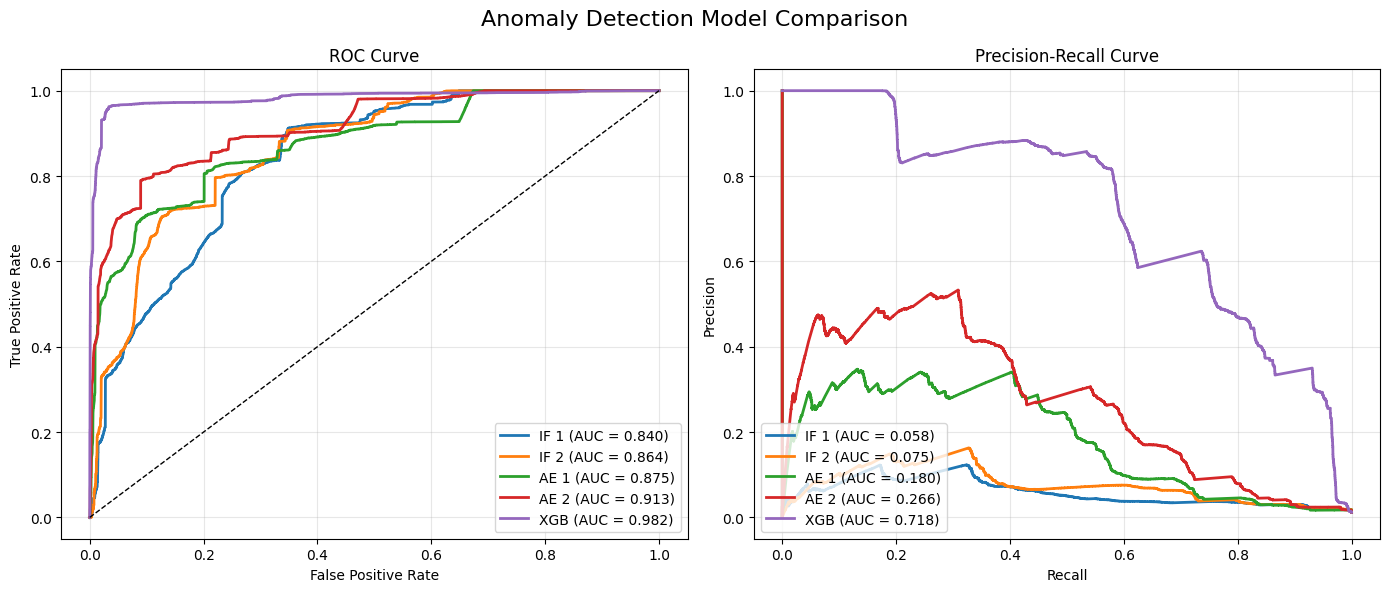

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. Define your initial models and scores
model_scores = {
    'IF 1': anomaly_score_if1,
    'IF 2': anomaly_score_if2,
    'AE 1': anomaly_score_ae1,
    'AE 2': anomaly_score_ae2,
    'XGB': anomaly_score_xgb
}

# 2. Initialize the master dictionary to store everything
model_results = {}

# Set up the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Anomaly Detection Model Comparison', fontsize=16)

# 3. Process each model and populate the dictionary
for model_name, scores in model_scores.items():
    
    # Initialize the nested dictionary for this specific model
    model_results[model_name] = {}
    model_results[model_name]['raw_scores'] = scores
    
    # --- ROC Calculations ---
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    model_results[model_name]['fpr'] = fpr
    model_results[model_name]['tpr'] = tpr
    model_results[model_name]['roc_auc'] = roc_auc
    
    # --- PR Calculations ---
    precision, recall, pr_thresholds = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall, precision)
    
    model_results[model_name]['precision'] = precision
    model_results[model_name]['recall'] = recall
    model_results[model_name]['pr_auc'] = pr_auc
    
    # --- F1 Score & Threshold Calculations ---
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
    
    # Align lengths: drop the last f1_score element to match thresholds array length
    f1_scores = f1_scores[:-1] 
    valid_f1_mask = ~np.isnan(f1_scores)
    best_idx = np.argmax(f1_scores[valid_f1_mask])
    
    opt_thresh = pr_thresholds[valid_f1_mask][best_idx]
    best_f1 = np.max(f1_scores[valid_f1_mask])
    
    model_results[model_name]['optimal_threshold'] = opt_thresh
    model_results[model_name]['best_f1'] = best_f1
    
    # --- Classifications ---
    y_pred = (scores >= opt_thresh).astype(int)
    model_results[model_name]['predictions'] = y_pred

    # --- Plotting ---
    ax_roc.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    ax_pr.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.3f})')
    
    # Print a quick summary to the console
    print(f"[{model_name}] Threshold: {opt_thresh:.4f} | F1: {best_f1:.4f} | ROC AUC: {roc_auc:.4f}")

# --- Format Subplots ---
# ROC Formatting
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# PR Formatting
ax_pr.set_title('Precision-Recall Curve')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Classification Report

In [53]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

print("================ MODEL COMPARISON SUMMARY ================\n")

summary_data = []

for model_name, results in model_results.items():
    y_pred = results['predictions']
    
    # --- Confusion Matrix Extraction ---
    # .ravel() flattens the 2x2 matrix into individual variables
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # --- False Positive Rate Calculation ---
    # FPR = FP / (FP + TN)
    # We add a quick check to prevent division by zero, just in case
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    # --- Standard Metrics ---
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0) # Recall is also your True Positive Rate (TPR)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    # Pulling AUCs directly from your existing dictionary
    roc_auc = results['roc_auc'] 
    pr_auc = results['pr_auc']   
    
    # Append all data as a new row in our summary
    summary_data.append({
        'Model': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'FPR': fpr_val,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc
    })

# Create the DataFrame
df_comparison = pd.DataFrame(summary_data)
df_comparison.set_index('Model', inplace=True)

# Format the float columns directly to 4 decimal places without using .style
cols_to_format = ['FPR', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']
for col in cols_to_format:
    df_comparison[col] = df_comparison[col].map('{:.4f}'.format)

# Print the clean table
print(df_comparison.to_string())

================ MODEL COMPARISON SUMMARY ================

            TN     FP     FN     TP     FPR Precision  Recall F1-Score ROC AUC  PR AUC
Model                                                                                 
IF 1   2037493  57564  16940   8097  0.0275    0.1233  0.3234   0.1785  0.8395  0.0579
IF 2   2052891  42166  16831   8206  0.0201    0.1629  0.3278   0.2176  0.8643  0.0747
AE 1   2075485  19572  14911  10126  0.0093    0.3410  0.4044   0.3700  0.8750  0.1802
AE 2   2080528  14529  15394   9643  0.0069    0.3989  0.3851   0.3919  0.9133  0.2663
XGB    2091756   3301  10530  14507  0.0016    0.8146  0.5794   0.6772  0.9825  0.7182


### Analysis

#### Unsupervised Comparison: Isolation Forest vs. Autoencoder
In a zero-day scenario, the gap between these two architectures becomes a chasm. The Autoencoder (AE) is the clear winner for novelty detection.

Isolation Forest Performance

- The Precision Trap: IF is performing very poorly here, with a Precision of only 0.12–0.16. This means that for every 10 novel attacks it flags, 8 or 9 are actually normal data.

- Why it fails here: IF works by isolating points. Novel attacks often mimic legitimate traffic patterns but with subtle deviations in internal logic. IF sees these as "clumped" with normal data rather than "isolated," causing it to miss them (low recall) or flag random normal outliers instead (low precision).

Autoencoder Performance

- Superior Logic: The AE shows a massive leap in PR AUC (0.26 vs 0.07). It is significantly better at distinguishing "normal" from "novel."

- Reconstruction Error: Because an AE learns the inherent structure and correlations of "normal" data, it doesn't need to have seen the attack before. When a novel attack arrives, it fails to "fit" the reconstruction template, triggering a flag.

- Efficiency: AE 2 achieved a Precision of 0.39, nearly triple that of the IF models. While 0.39 might seem low, in the world of zero-day detection, being right 40% of the time on things you've never seen before is actually quite respectable.



#### Unsupervised (AE) vs. Supervised Benchmark (XGB)

Usually, supervised models like XGBoost crumble when faced with novel attacks because they haven't been trained on those specific labels.

The "Humbled" Benchmark

- In our previous full dataset, XGB was near-perfect (F1 ~0.98). Here, its F1-Score has dropped to 0.67. This confirms these attacks are truly "novel"—the model is struggling to categorize them.

- Despite the drop, XGB still outperforms the AE. It maintains a Precision of 0.81 and Recall of 0.57.

- Why is XGB still on top? This suggests that while the attacks are "novel," they still share some underlying characteristics or feature distributions that the XGB model recognizes as "Not Normal." It isn't necessarily recognizing the attack; it has simply learned the boundary of "Normal" so tightly that it rejects the novel data more effectively than the unsupervised AE.

# Performance Metrics for best model

## Business KPI

### Alert Reduction

This metric measures the efficiency of your model in filtering out "noise." In cybersecurity, an IDS (Intrusion Detection System) that flags everything is useless.

- What it tells you: How much of the total network traffic was successfully ignored by the model.

- Business Value: A high alert reduction percentage means your security analysts aren't being buried under a mountain of data. It quantifies how much the model "cleans" the environment.

In [54]:
def alert_reduction(y_pred):
    total_flows = len(y_pred)
    alerts = np.sum(y_pred == 1)

    alert_rate = alerts / total_flows
    reduction = 1 - alert_rate

    return {
        "total_flows": total_flows,
        "alerts_generated": alerts,
        "alert_rate": alert_rate,
        "alert_reduction_percent": reduction * 100
    }

In [70]:
alert_reduction_df = pd.DataFrame(
    [
        alert_reduction(y_test),
        alert_reduction(model_results['XGB']['predictions']),
        alert_reduction(model_results['AE 2']['predictions'])
    ],
    index=['dataset','XGB','AE']
)
alert_reduction_df

,total_flows,alerts_generated,alert_rate,alert_reduction_percent
dataset,2120094,25037,0.011809,98.819062
XGB,2120094,17808,0.008400,99.160037
AE,2120094,24172,0.011401,98.859862


With this, we have our benchmark from our original dataset's distribution. More alert reduction means we are not being buried with alarms proportional to the amount of flow

### Top-K Detection (Precision at k)

This evaluates how well the model prioritizes the most dangerous threats by looking only at the "top" highest-probability scores.

- What it tells you: If an analyst only has time to look at the top 5% (k=0.05) of high-score alerts, what percentage of actual attacks would they catch?

- Business Value: This helps with resource allocation. It proves whether the model’s scoring system is reliable enough to catch the majority of threats even when staff is limited.

In [88]:
def top_k_detection(y_true, scores, k=0.05):
    df = pd.DataFrame({
        "y_true": y_true,
        "score": scores
    })

    df = df.sort_values("score", ascending=False)

    top_k_n = int(len(df) * k)
    top_k = df.head(top_k_n)

    attacks_total = np.sum(df["y_true"] == 1)
    attacks_found = np.sum(top_k["y_true"] == 1)

    detection_rate = attacks_found / attacks_total

    return {
        "top_k_percent": k * 100,
        "attacks_found": attacks_found,
        "total_attacks": attacks_total,
        "top_k_detection_rate": detection_rate
    }

In [89]:
topk_df = pd.DataFrame(
    [
        top_k_detection(y_test,model_results['AE 2']['raw_scores']),
        top_k_detection(y_test,model_results['XGB']['raw_scores'])
    ],
    index=['AE','XGB']
)
topk_df

,top_k_percent,attacks_found,total_attacks,top_k_detection_rate
AE,5.0,17040,25037,0.680593
XGB,5.0,24153,25037,0.964692


This tells that just at a glance, XGB model can reliably tell that a detection is 96% real

In [90]:
topk_df = pd.DataFrame(
    [
        top_k_detection(y_test,model_results['AE 2']['raw_scores'], k=0.37),
        top_k_detection(y_test,model_results['XGB']['raw_scores'], k=0.37)
    ],
    index=['AE','XGB']
)
topk_df

,top_k_percent,attacks_found,total_attacks,top_k_detection_rate
AE,37.0,22598,25037,0.902584
XGB,37.0,24803,25037,0.990654


With [CROGL's report](https://www.forbes.com/sites/tonybradley/2026/03/18/your-soc-is-investigating-less-than-half-its-alerts-every-day/), a team of 7 managing an SOC can investigate 37% of 4330 alerts in a day. And with that, XGB still wins the game by reliably telling a detection is 99% real

### False Alert Cost

This converts technical errors (False Positives) into a concrete monetary value.

- What it tells you: The literal monetary amount wasted by human analysts investigating "ghost" threats that weren't actually attacks.

- Business Value: This is the most important KPI. It justifies the ROI (Return on Investment) of a better model.

In [91]:
def false_alert_cost(y_true, y_pred,
                     minutes_per_alert=7,
                     analyst_hourly_cost=337,
                     daily_alerts=4330):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_alerts = tn + fp

    hours_wasted = (fp * minutes_per_alert) / 60
    cost = hours_wasted * analyst_hourly_cost
    annual_cost = 365 *  cost * daily_alerts / total_alerts

    return {
        "total_alerts": total_alerts,
        "false_positives": fp,
        "hours_wasted": hours_wasted,
        "estimated_cost": cost,
        "annual_cost": annual_cost
    }

In [93]:
false_alert_cost_df = pd.DataFrame(
    [
        false_alert_cost(y_test,model_results['XGB']['predictions']),
        false_alert_cost(y_test,model_results['AE 2']['predictions'])
    ],
    index=['XGB','AE']
)
false_alert_cost_df

,total_alerts,false_positives,hours_wasted,estimated_cost,annual_cost
XGB,2095057,3301,385.116667,129784.316667,97905.509624
AE,2095057,14529,1695.050000,571231.850000,430920.675348


With the results above, XGB still is the better model than Autoencoder, offering ~300k Php in annual false alert cost

# Conclusion

With the technical and business metrics, XGB offers the best choice as model for network intrusion detection system. Even as a supervised model, it proved to be better at detecting novel attacks than unsupervised models. But this also comes at a caveat that the developer only has rudimentary skills and knowledge in machine learning and might not employ what the model/algorithm can best offer.